In [ ]:
!pip install lime dice-ml scikit-learn pandas numpy matplotlib

In [2]:
import pandas as pd

# Load Adult Income Dataset from GitHub
url = "https://raw.githubusercontent.com/JoJmH/XAI-report/refs/heads/main/adult.csv"
df = pd.read_csv(url)

# Preview
print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
from sklearn.preprocessing import LabelEncoder

# Drop rows with missing values marked as '?'
df = df[~df.isin(['?']).any(axis=1)]

# Convert income to binary: we want 1 for >50K (our positive class) and 0 otherwise
# this is the target variable for the clasification task
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

# The Adult dataset has several categorical features like occupation and gender
# We need to encode these as numbers so our classifier can process them
label_encoder = LabelEncoder()
categorical_features = df.select_dtypes(include='object').columns

for feature in categorical_features:
    df[feature] = label_encoder.fit_transform(df[feature])

# confirm dataset size after cleaning
print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nIncome class distribution:\n{df['income'].value_counts()}")


Dataset shape after cleaning: (45222, 15)

Income class distribution:
income
0    34014
1    11208
Name: count, dtype: int64


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# separate feature from target variable
X = df.drop('income', axis=1)
y = df['income']

# split data into train and test sets(80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest classifier on the Adult Income Dataset
# This is our black-box model that LIME and DiCE will later explain
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#  accuracy check
accuracy = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Model accuracy: {accuracy:.2f}")

Model accuracy: 0.86


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


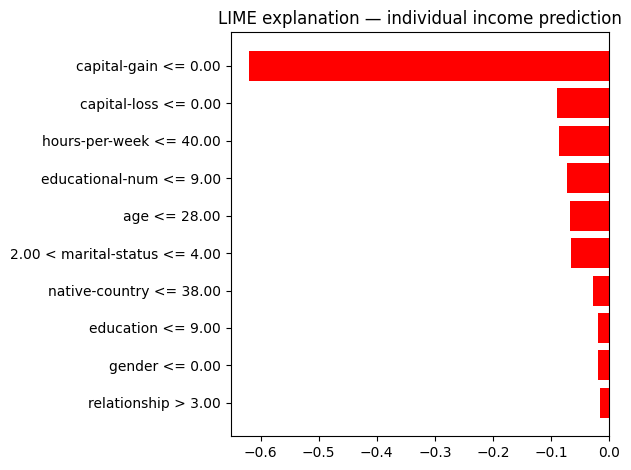

In [6]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# Set up LIME explainer using the training data as reference
# This tells LIME what "normal" data looks like
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['<=50K', '>50K'],
    mode='classification'
)

# Pick one instance from the test set to explain
# We choose someone the model predicted as low income (<=50K)
instance = X_test.iloc[0].values

# Generate the LIME explanation for this instance
explanation = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=rf_model.predict_proba,
    num_features=10
)

# Visualise the explanation
explanation.as_pyplot_figure()
plt.title("LIME explanation — individual income prediction")
plt.tight_layout()
plt.show()

In [8]:
import dice_ml

# Tell DiCE about the dataset and which column is the target
dice_data = dice_ml.Data(
    dataframe=df,
    continuous_features=['age', 'fnlwgt', 'educational-num',
                         'capital-gain', 'capital-loss', 'hours-per-week'],
    outcome_name='income'
)

# wrap the trained model for DiCE
dice_model = dice_ml.Model(model=rf_model, backend='sklearn')

# create the DiCE explainer
dice_explainer = dice_ml.Dice(dice_data, dice_model, method='random')


In [13]:
# Take the same instance we used for LIME so we can compare directly
instance_df = X_test.iloc[[0]]

# Generate 3 diverse counterfactuals for this person
# We want to see what would need to change to flip prediction to >50K
dice_exp = dice_explainer.generate_counterfactuals(
    instance_df,
    total_CFs=3,
    desired_class='opposite'
)

# Display the counterfactuals as a table
dice_exp.visualize_as_dataframe(show_only_changes=True)

  0%|          | 0/1 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-p

Query instance (original outcome : 0)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,19,4,30800,0,6,3,0,4,0,0,0,0,40,38,0



Diverse Counterfactual set (new outcome: 1)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,-,-,-,-,-,-,12,-,-,-,92035,-,-,-,1
1,-,-,-,-,-,-,-,-,-,1,99265,-,-,-,1
2,-,-,-,2,-,-,-,-,-,-,89848,-,-,-,1


In [10]:
# How often does changing ONLY gender flip the prediction?
# This is our bias diagnostic — not a recommendation

X_test_gender_flipped = X_test.copy()

# Flip gender: 0 becomes 1 and 1 becomes 0
X_test_gender_flipped['gender'] = 1 - X_test_gender_flipped['gender']

# Get predictions for original and gender-flipped versions
original_preds = rf_model.predict(X_test)
flipped_preds = rf_model.predict(X_test_gender_flipped)

# Count how many predictions changed purely due to gender flip
n_flipped = (original_preds != flipped_preds).sum()
flip_rate = n_flipped / len(original_preds)

print(f"Total test instances: {len(original_preds)}")
print(f"Predictions changed by gender flip: {n_flipped}")
print(f"Counterfactual flip rate (gender only): {flip_rate:.2%}")

Total test instances: 9045
Predictions changed by gender flip: 480
Counterfactual flip rate (gender only): 5.31%


In [11]:
# Which DiCE suggestions are actionable vs non-actionable?
# Non-actionable = features a person cannot realistically change (age, gender, race)

non_actionable_features = ['age', 'gender', 'race']

# Run DiCE on 10 instances and check if non-actionable features appear in suggestions
actionable_count = 0
non_actionable_count = 0

for i in range(10):
    instance_i = X_test.iloc[[i]]
    exp_i = dice_explainer.generate_counterfactuals(
        instance_i,
        total_CFs=3,
        desired_class='opposite',
        random_seed=42
    )
    cf_df = exp_i.cf_examples_list[0].final_cfs_df
    original = instance_i.values[0]

    for _, cf_row in cf_df.iterrows():
        changed = [col for col in X_test.columns
                   if cf_row[col] != original[X_test.columns.get_loc(col)]]
        if any(f in changed for f in non_actionable_features):
            non_actionable_count += 1
        else:
            actionable_count += 1

total = actionable_count + non_actionable_count
print(f"Actionable counterfactuals: {actionable_count} ({actionable_count/total:.0%})")
print(f"Non-actionable counterfactuals: {non_actionable_count} ({non_actionable_count/total:.0%})")

  0%|          | 0/1 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/dice_ml/explainer_interfaces/dice_random.py:116: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  candidate_cfs.at[k, selected_features[k][0]] = random_instances.at[k, selected_features[k][0]]
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-pa

Actionable counterfactuals: 25 (83%)
Non-actionable counterfactuals: 5 (17%)
